In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving business_analytics_dataset.csv to business_analytics_dataset.csv


In [3]:
data= pd.read_csv('business_analytics_dataset.csv')

In [4]:
data.head()

,Customer_ID,Age,Gender,Income,Purchase_History,Spending_Score,Product_Category,Last_Purchase_Amount,Churn
0,CUST0001,56,Male,65648,High,17,Groceries,201,Yes
1,CUST0002,69,Male,123537,High,68,Electronics,14,No
2,CUST0003,46,Male,145991,Medium,47,Fashion,1923,No
3,CUST0004,32,Female,29516,High,25,Fashion,1270,No
4,CUST0005,60,Male,132863,Medium,94,Electronics,1726,No


In [5]:
# Drop Customer_ID as it is not useful for modeling
data = data.drop(columns=['Customer_ID'])

In [6]:
# Encode categorical variables
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Purchase_History'] = label_encoder.fit_transform(data['Purchase_History'])
data['Product_Category'] = label_encoder.fit_transform(data['Product_Category'])
data['Churn'] = label_encoder.fit_transform(data['Churn'])  # Target variable

In [7]:
# Split the data into features and target
X = data.drop(columns=['Churn'])
y = data['Churn']

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Build and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
# Evaluate the model
predictions = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.94      0.82       144
           1       0.40      0.11      0.17        56

    accuracy                           0.70       200
   macro avg       0.56      0.52      0.49       200
weighted avg       0.64      0.70      0.64       200



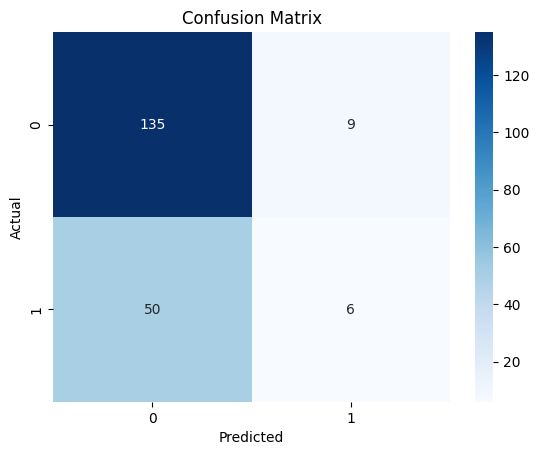

In [11]:


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




In [12]:
# Calculate AUC-ROC
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"AUC-ROC Score: {roc_auc:.2f}")

AUC-ROC Score: 0.45
